# 第8章 文埋め込み

## 8.3 文埋め込みモデルの実装

### pipelineを使用してファインチューニングしたモデルの検証

In [1]:
# 必要なパッケージをインストールする
!pip install 'datasets<4.0.0' scipy 'transformers[ja,torch]<4.41.0'

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 138.0/138.0 kB 13.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.4/13.4 MB 33.8 MB/s eta 0:00:0000:0100:01
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.4/47.4 MB 29.4 MB/s eta 0:00:0000:0100:01
  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 491.5/491.5 kB 44.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.0/9.0 MB 157.9 MB/s eta 0:00:0000:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 694.9/694.9 kB 57.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 52.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 86.8/86.8 kB 11.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.2/72.2 MB 37.7 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 95.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

#### 1. Driveをマウント

In [2]:
from google.colab import drive
drive.mount("/content/drive")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


: 

## unsupervised model

#### 2. Driveからモデルをローカルにコピー（読み込み高速化のため）

In [3]:
!cp -r /content/drive/MyDrive/llm-book/outputs_unsup_simcse ./

: 

#### 3. pipelineで読み込み

In [4]:
from transformers import pipeline
encoder_path = "outputs_unsup_simcse/encoder"

# 文埋め込み用にfeature-extractionタスクを指定
embedder = pipeline(
    task="feature-extraction",
    model=encoder_path,
    tokenizer=encoder_path,
    device=0,  # GPU使用。CPUなら-1
)

: 

#### 4. 動作確認: 文埋め込みを取得

In [5]:
import torch
import torch.nn.functional as F

sentences = [
    "今日は天気が良い",
    "本日は晴天です",
    "猫がソファで寝ている",
]

# 各文の[CLS]トークンのベクトルを取得
embeddings = []
for s in sentences:
    out = embedder(s)  # shape: (1, seq_len, hidden_size)
    cls_vec = torch.tensor(out[0][0])  # [CLS]トークン = 0番目
    embeddings.append(cls_vec)

embeddings = torch.stack(embeddings)

: 

#### 5. コサイン類似度で確認

In [6]:
import torch
import torch.nn.functional as F

cls_vecs: list[torch.Tensor] = []
for s in sentences:
    out = embedder(s)
    cls_vecs.append(torch.tensor(out[0][0]))

# Tensorに変換（別名で受ける）
embeddings: torch.Tensor = torch.stack(cls_vecs)

sim_matrix = F.cosine_similarity(
    embeddings.unsqueeze(1),
    embeddings.unsqueeze(0),
    dim=2,
)
print(sim_matrix)

tensor([[1.0000, 0.9289, 0.4385],
        [0.9289, 1.0000, 0.4331],
        [0.4385, 0.4331, 1.0000]])


: 

In [12]:
! pip install seaborn matplotlib japanize-matplotlib

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.1/4.1 MB 115.3 MB/s eta 0:00:0000:01
  Preparing metadata (setup.py) ... done
  Created wheel for japanize-matplotlib: filename=japanize_matplotlib-1.1.3-py3-none-any.whl size=4120257 sha256=96bdc658d1387d354b54154fd55cf4ab262d6a958087f9719be935d0d11b9125
  Stored in directory: /root/.cache/pip/wheels/c1/f7/9b/418f19a7b9340fc16e071e89efc379aca68d40238b258df53d
Successfully built japanize-matplotlib


: 

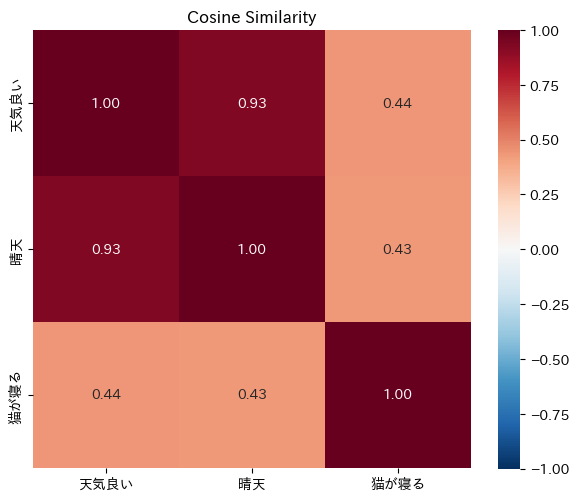

: 

In [13]:
import seaborn as sns
import matplotlib.pyplot as plt
import japanize_matplotlib

# GPUにあるTensorをCPU/numpyに変換
sim_np = sim_matrix.cpu().numpy()

# 文を短いラベルに（長すぎると見づらいため）
labels = ["天気良い", "晴天", "猫が寝る"]

plt.figure(figsize=(6, 5))
sns.heatmap(
    sim_np,
    annot=True,        # 数値を表示
    fmt=".2f",         # 小数点2桁
    cmap="RdBu_r",     # 赤-青のカラーマップ
    vmin=-1, vmax=1,   # 類似度の範囲
    xticklabels=labels,
    yticklabels=labels,
    square=True,
)
plt.title("Cosine Similarity")
plt.tight_layout()
plt.show()


## supervised model

#### 2. Driveからモデルをローカルにコピー（読み込み高速化のため）

In [ ]:
!cp -r /content/drive/MyDrive/llm-book/outputs_sup_simcse ./

: 

#### 3. pipelineで読み込み

In [ ]:
from transformers import pipeline
encoder_path = "outputs_sup_simcse/encoder"

# 文埋め込み用にfeature-extractionタスクを指定
embedder = pipeline(
    task="feature-extraction",
    model=encoder_path,
    tokenizer=encoder_path,
    device=0,  # GPU使用。CPUなら-1
)

: 

#### 4. 動作確認: 文埋め込みを取得

In [ ]:
import torch
import torch.nn.functional as F

sentences = [
    "今日は天気が良い",
    "本日は晴天です",
    "猫がソファで寝ている",
]

# 各文の[CLS]トークンのベクトルを取得
embeddings = []
for s in sentences:
    out = embedder(s)  # shape: (1, seq_len, hidden_size)
    cls_vec = torch.tensor(out[0][0])  # [CLS]トークン = 0番目
    embeddings.append(cls_vec)

embeddings = torch.stack(embeddings)

: 

#### 5. コサイン類似度で確認

In [ ]:
import torch
import torch.nn.functional as F

cls_vecs: list[torch.Tensor] = []
for s in sentences:
    out = embedder(s)
    cls_vecs.append(torch.tensor(out[0][0]))

# Tensorに変換（別名で受ける）
embeddings: torch.Tensor = torch.stack(cls_vecs)

sim_matrix = F.cosine_similarity(
    embeddings.unsqueeze(1),
    embeddings.unsqueeze(0),
    dim=2,
)
print(sim_matrix)

tensor([[1.0000, 0.9289, 0.4385],
        [0.9289, 1.0000, 0.4331],
        [0.4385, 0.4331, 1.0000]])


: 

In [ ]:
! pip install seaborn matplotlib japanize-matplotlib

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.1/4.1 MB 115.3 MB/s eta 0:00:0000:01
  Preparing metadata (setup.py) ... done
  Created wheel for japanize-matplotlib: filename=japanize_matplotlib-1.1.3-py3-none-any.whl size=4120257 sha256=96bdc658d1387d354b54154fd55cf4ab262d6a958087f9719be935d0d11b9125
  Stored in directory: /root/.cache/pip/wheels/c1/f7/9b/418f19a7b9340fc16e071e89efc379aca68d40238b258df53d
Successfully built japanize-matplotlib


: 

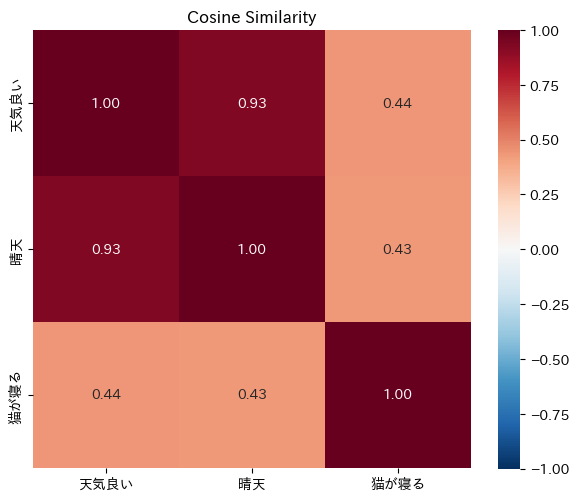

: 

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import japanize_matplotlib

# GPUにあるTensorをCPU/numpyに変換
sim_np = sim_matrix.cpu().numpy()

# 文を短いラベルに（長すぎると見づらいため）
labels = ["天気良い", "晴天", "猫が寝る"]

plt.figure(figsize=(6, 5))
sns.heatmap(
    sim_np,
    annot=True,        # 数値を表示
    fmt=".2f",         # 小数点2桁
    cmap="RdBu_r",     # 赤-青のカラーマップ
    vmin=-1, vmax=1,   # 類似度の範囲
    xticklabels=labels,
    yticklabels=labels,
    square=True,
)
plt.title("Cosine Similarity")
plt.tight_layout()
plt.show()


: 